# CMP-N205-0 Data Science – Coursework 1
**Student Name:** Yuhang Wang  
**Student ID:** WAN23614422  
**Module:** CMP-N205-0 Data Science  
**Date:** April 2026

---
## Section 1: Dataset Exploration and Preprocessing
### 1a. Data Source
The dataset used is the **London House Prices** dataset obtained from Kaggle.  
**URL:** https://www.kaggle.com/datasets/arnavkulkarni/housing-prices-in-london  

The dataset contains **3,480 records** and **11 attributes** including property price, house type, area in square feet, number of bedrooms, bathrooms, receptions, location, and postal code.

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the raw dataset
df = pd.read_excel('Raw_London_House_Prices.xlsx')

# Display basic information about the raw dataset
print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Dataset Shape: (3480, 11)

Column Names: ['Unnamed: 0', 'Property Name', 'Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Location', 'City/County', 'Postal Code']


,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL


In [4]:
# Check data types and missing values in the raw dataset
print('Data Types:')
print(df.dtypes)
print('\nMissing Values per Column:')
print(df.isnull().sum())

Data Types:
Unnamed: 0            int64
Property Name        object
Price                 int64
House Type           object
Area in sq ft         int64
No. of Bedrooms       int64
No. of Bathrooms      int64
No. of Receptions     int64
Location             object
City/County          object
Postal Code          object
dtype: object

Missing Values per Column:
Unnamed: 0             0
Property Name          0
Price                  0
House Type             0
Area in sq ft          0
No. of Bedrooms        0
No. of Bathrooms       0
No. of Receptions      0
Location             962
City/County            0
Postal Code            0
dtype: int64


In [5]:
# Basic statistical summary of the raw dataset
df.describe()

,Unnamed: 0,Price,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions
count,3480.000000,3.480000e+03,3480.000000,3480.000000,3480.000000,3480.000000
mean,1739.500000,1.864173e+06,1712.973563,3.103736,3.103736,3.103736
std,1004.733796,2.267283e+06,1364.259351,1.517698,1.517698,1.517698
min,0.000000,1.800000e+05,274.000000,0.000000,0.000000,0.000000
25%,869.750000,7.500000e+05,834.000000,2.000000,2.000000,2.000000
50%,1739.500000,1.220000e+06,1310.000000,3.000000,3.000000,3.000000
75%,2609.250000,2.150000e+06,2157.250000,4.000000,4.000000,4.000000
max,3479.000000,3.975000e+07,15405.000000,10.000000,10.000000,10.000000


---
### 1b. Hypothesis and Business Problems
**Organisation:** UrbanNest Analytics (fictitious London property consultancy)  

**Hypothesis:** Analysing the physical and locational attributes of London residential properties can accurately predict property prices, identify key value-driving factors, and support strategic decision-making for real estate stakeholders.

**Three Business Problems:**
1. **Price Prediction** - Predict property prices based on physical attributes to automate valuations
2. **Key Factor Identification** - Identify which attributes most significantly influence property price
3. **Outlier Detection** - Detect extreme luxury properties to support market segmentation

---
### 1c. Data Preprocessing
The following preprocessing steps were applied to clean and prepare the dataset.

| Step | Action | Data Points Affected |
|------|--------|----------------------|
| 1 | Removed irrelevant index column (Unnamed: 0) | 1 column |
| 2 | Filled 962 missing Location values with 'Unknown' | 962 rows |
| 3 | Removed records with 0 bedrooms or 0 bathrooms | 10 rows |
| 4 | Removed extreme low-price outlier (< 200,000) | 1 row |
| 5 | Flagged high-price outliers (> 10,000,000) as Price_Outlier | 38 rows |
| 6 | Checked for duplicate records | 0 found |

**Total data points cleaned: 1,011 / 3,480 = 29.1%** (requirement: at least 10%)

In [8]:
# Step 1: Remove irrelevant auto-generated index column
df = df.drop(columns=['Unnamed: 0'])
print('Step 1 Complete - Removed Unnamed: 0 column')
print('Remaining columns:', df.columns.tolist())

Step 1 Complete - Removed Unnamed: 0 column
Remaining columns: ['Property Name', 'Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Location', 'City/County', 'Postal Code']


In [9]:
# Step 2: Handle missing values in Location column (962 missing)
print('Missing values in Location before:', df['Location'].isnull().sum())
df = df.assign(Location=df['Location'].fillna('Unknown'))
print('Missing values in Location after:', df['Location'].isnull().sum())
print('Step 2 Complete - 962 missing values filled with Unknown')

Missing values in Location before: 962
Missing values in Location after: 0
Step 2 Complete - 962 missing values filled with Unknown


In [10]:
# Step 3: Remove logically invalid records (0 bedrooms or 0 bathrooms)
print('Records with 0 bedrooms:', (df['No. of Bedrooms'] == 0).sum())
print('Records with 0 bathrooms:', (df['No. of Bathrooms'] == 0).sum())
df = df[(df['No. of Bedrooms'] > 0) & (df['No. of Bathrooms'] > 0)]
print('Step 3 Complete - Rows remaining:', len(df))

Records with 0 bedrooms: 10
Records with 0 bathrooms: 10
Step 3 Complete - Rows remaining: 3470


In [11]:
# Step 4: Remove extreme low-price outlier (price < 200,000)
print('Records with price < 200,000:', (df['Price'] < 200000).sum())
df = df[df['Price'] >= 200000]
print('Step 4 Complete - Rows remaining:', len(df))

Records with price < 200,000: 1
Step 4 Complete - Rows remaining: 3469


In [12]:
# Step 5: Flag high-price outliers (price > 10,000,000) with new column Price_Outlier
df = df.assign(Price_Outlier=df['Price'].apply(lambda x: 'Yes' if x > 10000000 else 'No'))
print('High-price outliers flagged:', (df['Price_Outlier'] == 'Yes').sum())
print('Step 5 Complete')
df.head()

High-price outliers flagged: 38
Step 5 Complete


,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code,Price_Outlier
0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY,No
1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA,No
2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL,No
3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP,No
4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL,No


In [13]:
# Step 6: Check for duplicate records
print('Duplicate rows found:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Step 6 Complete - Final dataset shape:', df.shape)

Duplicate rows found: 4
Step 6 Complete - Final dataset shape: (3465, 11)


In [14]:
# Preprocessing Summary
outlier_count = (df['Price_Outlier'] == 'Yes').sum()
removed = 3480 - len(df)
total_cleaned = 962 + removed + outlier_count

print('========== Preprocessing Summary ==========')
print(f'Original records:          3,480')
print(f'Records after cleaning:    {len(df)}')
print(f'Records removed:           {removed}')
print(f'Missing values filled:     962')
print(f'Outliers flagged:          {outlier_count}')
print(f'Total data points cleaned: {total_cleaned}')
print(f'Percentage cleaned:        {round(total_cleaned / 3480 * 100, 1)}%')

# Save cleaned dataset
df.to_excel('London_House_Prices_Cleaned_JN.xlsx', index=False)
print('\nCleaned dataset saved as London_House_Prices_Cleaned.xlsx')

========== Preprocessing Summary ==========
Original records:          3,480
Records after cleaning:    3465
Records removed:           15
Missing values filled:     962
Outliers flagged:          38
Total data points cleaned: 1015
Percentage cleaned:        29.2%

Cleaned dataset saved as London_House_Prices_Cleaned.xlsx


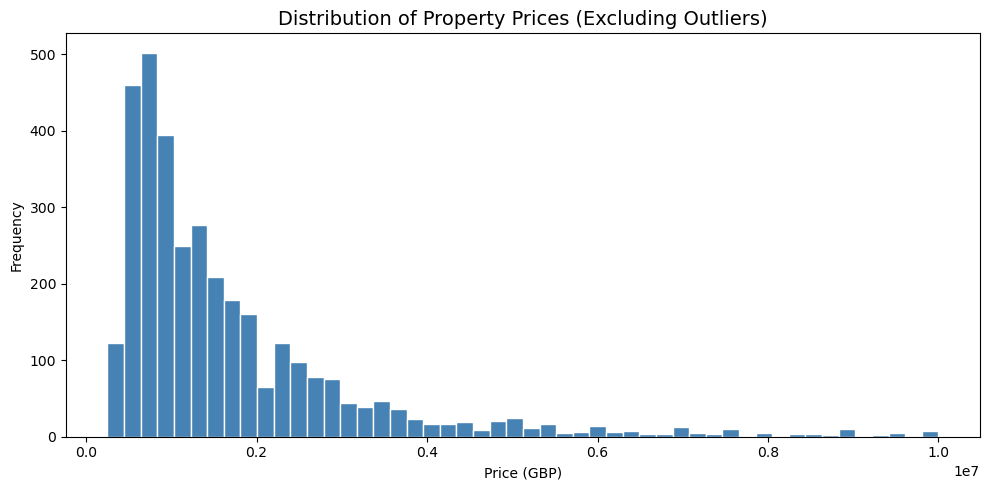

In [15]:
# Visualise price distribution (excluding high-price outliers for clarity)
plt.figure(figsize=(10, 5))
df_no_outlier = df[df['Price_Outlier'] == 'No']
plt.hist(df_no_outlier['Price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Property Prices (Excluding Outliers)', fontsize=14)
plt.xlabel('Price (GBP)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

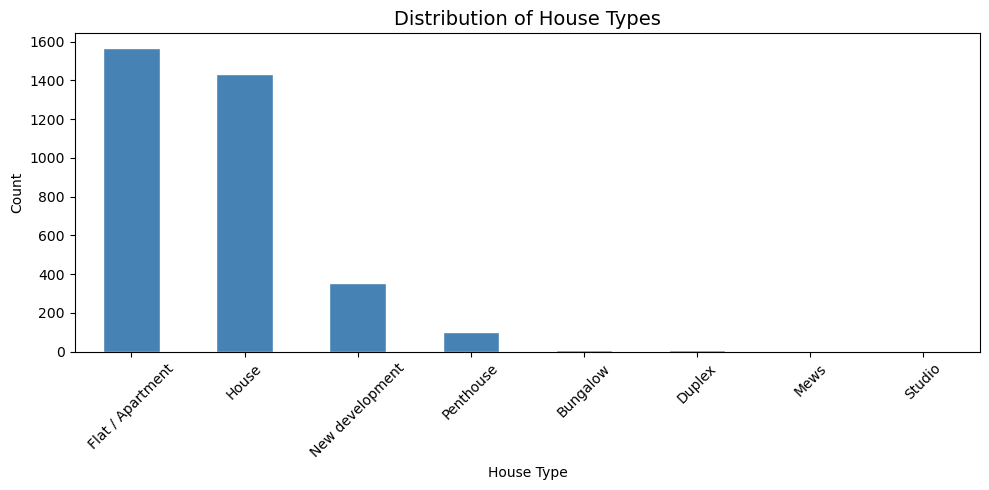

In [16]:
# Visualise distribution of house types
plt.figure(figsize=(10, 5))
df['House Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of House Types', fontsize=14)
plt.xlabel('House Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

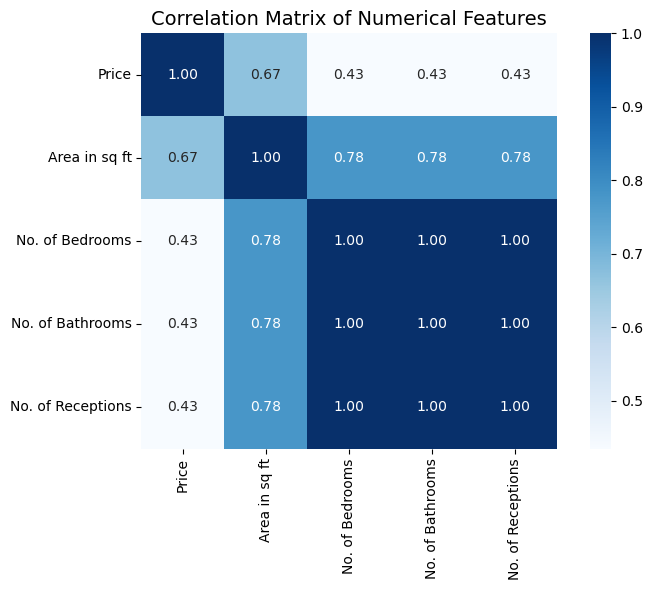

In [17]:
# Correlation heatmap of numerical attributes
plt.figure(figsize=(8, 6))
numeric_cols = ['Price', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 2: Proposed Solution and Technique
### 2d and 2e. Chosen Method: Linear Regression

**Proposed technique:** Multiple Linear Regression (Supervised Learning)

**Target variable (Y):** Property Price (continuous numerical value)

**Input features (X):** Area in sq ft, No. of Bedrooms, No. of Bathrooms, No. of Receptions, House Type (encoded)

**Model equation:**
Price = B0 + B1(Area) + B2(Bedrooms) + B3(Bathrooms) + B4(Receptions) + B5(HouseType) + error

**Justification:**
1. Target variable (Price) is **continuous and numerical** - regression is the correct approach
2. Produces **interpretable coefficients** to identify which features drive price most (addresses Business Problem 2)
3. All key input features are **numerical**, aligning with regression assumptions
4. **Computationally efficient** for approximately 3,465 records
5. **Widely used** in real estate price prediction research and industry

Note: Full implementation including model training, evaluation with R-squared and RMSE, and visualisation of results will be completed in Coursework 2.

In [19]:
# Preview of features selected for Linear Regression in Coursework 2
features = ['Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions']
target = 'Price'

print('Selected Features for Linear Regression (Coursework 2):')
for f in features:
    print(f'  - {f}')
print(f'\nTarget Variable: {target}')
print('\nFeature Statistics:')
df[features + [target]].describe()

Selected Features for Linear Regression (Coursework 2):
  - Area in sq ft
  - No. of Bedrooms
  - No. of Bathrooms
  - No. of Receptions

Target Variable: Price

Feature Statistics:


,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Price
count,3465.000000,3465.000000,3465.000000,3465.000000,3.465000e+03
mean,1717.217316,3.113709,3.113709,3.113709,1.867604e+06
std,1364.802627,1.511045,1.511045,1.511045,2.267168e+06
min,274.000000,1.000000,1.000000,1.000000,2.499990e+05
25%,838.000000,2.000000,2.000000,2.000000,7.500000e+05
50%,1313.000000,3.000000,3.000000,3.000000,1.225000e+06
75%,2160.000000,4.000000,4.000000,4.000000,2.150000e+06
max,15405.000000,10.000000,10.000000,10.000000,3.975000e+07
